In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import zscore

In [2]:
# Load datasets
datasets = {
    "YouTube": "/kaggle/input/final-data/videos_all.csv",
    "YouTube_Corpus": "/kaggle/input/final-data/transcript_corpus.csv",
    "Twitter": "/kaggle/input/final-data/twitter.csv",
    "Twitter_Corpus": "/kaggle/input/final-data/tweets_corpus.csv",
    "Speeches": "/kaggle/input/final-data/speeches.csv",
    "Speeches_Corpus": "/kaggle/input/final-data/speeches_new_corpus.csv"
}

# Define text column names
text_columns = {
    "YouTube": "transcript_clean",
    "Twitter": "text_clean",
    "Speeches": "text"
}

date_columns = {
    "YouTube": "published_at",
    "Twitter": "created_at",
    "Speeches": "date"
}


In [3]:
colors = {"evidence": "#228833", "intuition": "#DDCC77"}
# Function to compute clipped scores ensuring only positive values are averaged
def compute_clipped_scores(transcript, corpus_dict):
    words = transcript.split()  # Tokenize transcript
    evidence_scores = []
    intuition_scores = []

    for word in words:
        if word in corpus_dict:
            if corpus_dict[word]['evidence_score'] > 0:
                evidence_scores.append(corpus_dict[word]['evidence_score'])
            if corpus_dict[word]['intuition_score'] > 0:
                intuition_scores.append(corpus_dict[word]['intuition_score'])

    # Compute averages, avoiding division by zero
    evidence_score_clipped = sum(evidence_scores) / len(evidence_scores) if evidence_scores else 0
    intuition_score_clipped = sum(intuition_scores) / len(intuition_scores) if intuition_scores else 0

    return evidence_score_clipped, intuition_score_clipped



# Define a function to perform bootstrapping and calculate confidence intervals
def bootstrap_ci(data, num_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(num_bootstrap):
        sample = data.sample(frac=1, replace=True)
        boot_means.append(sample.mean())
    lower_bound = np.percentile(boot_means, (100 - ci) / 2)
    upper_bound = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound


def length_adjustment_bin(df, length_column, model_str, minimum_length=0):
    bins = range(minimum_length, df[length_column].max()+10, 10)
    df[f'{length_column}_bin'] = pd.cut(df[length_column], bins=bins)
    df[f'evidence_mean_{model_str}'] = df.groupby(f'{length_column}_bin')[f'evidence_score_{model_str}'].transform('mean')
    df[f'evidence_adj_{model_str}'] = df[f'evidence_score_{model_str}'] - df[f'evidence_mean_{model_str}']
    df[f'intuition_mean_{model_str}'] = df.groupby(f'{length_column}_bin')[f'intuition_score_{model_str}'].transform('mean')
    df[f'intuition_adj_{model_str}'] = df[f'intuition_score_{model_str}'] - df[f'intuition_mean_{model_str}']
    return df
    
def evidence_minus_intuition_score(df, model_str):
    df[[f'evidence_z_{model_str}', f'intuition_z_{model_str}']] = df[[f'evidence_adj_{model_str}', f'intuition_adj_{model_str}']].apply(zscore)
    df[f'emi_{model_str}'] = df[f'evidence_z_{model_str}'] - df[f'intuition_z_{model_str}']
    return df

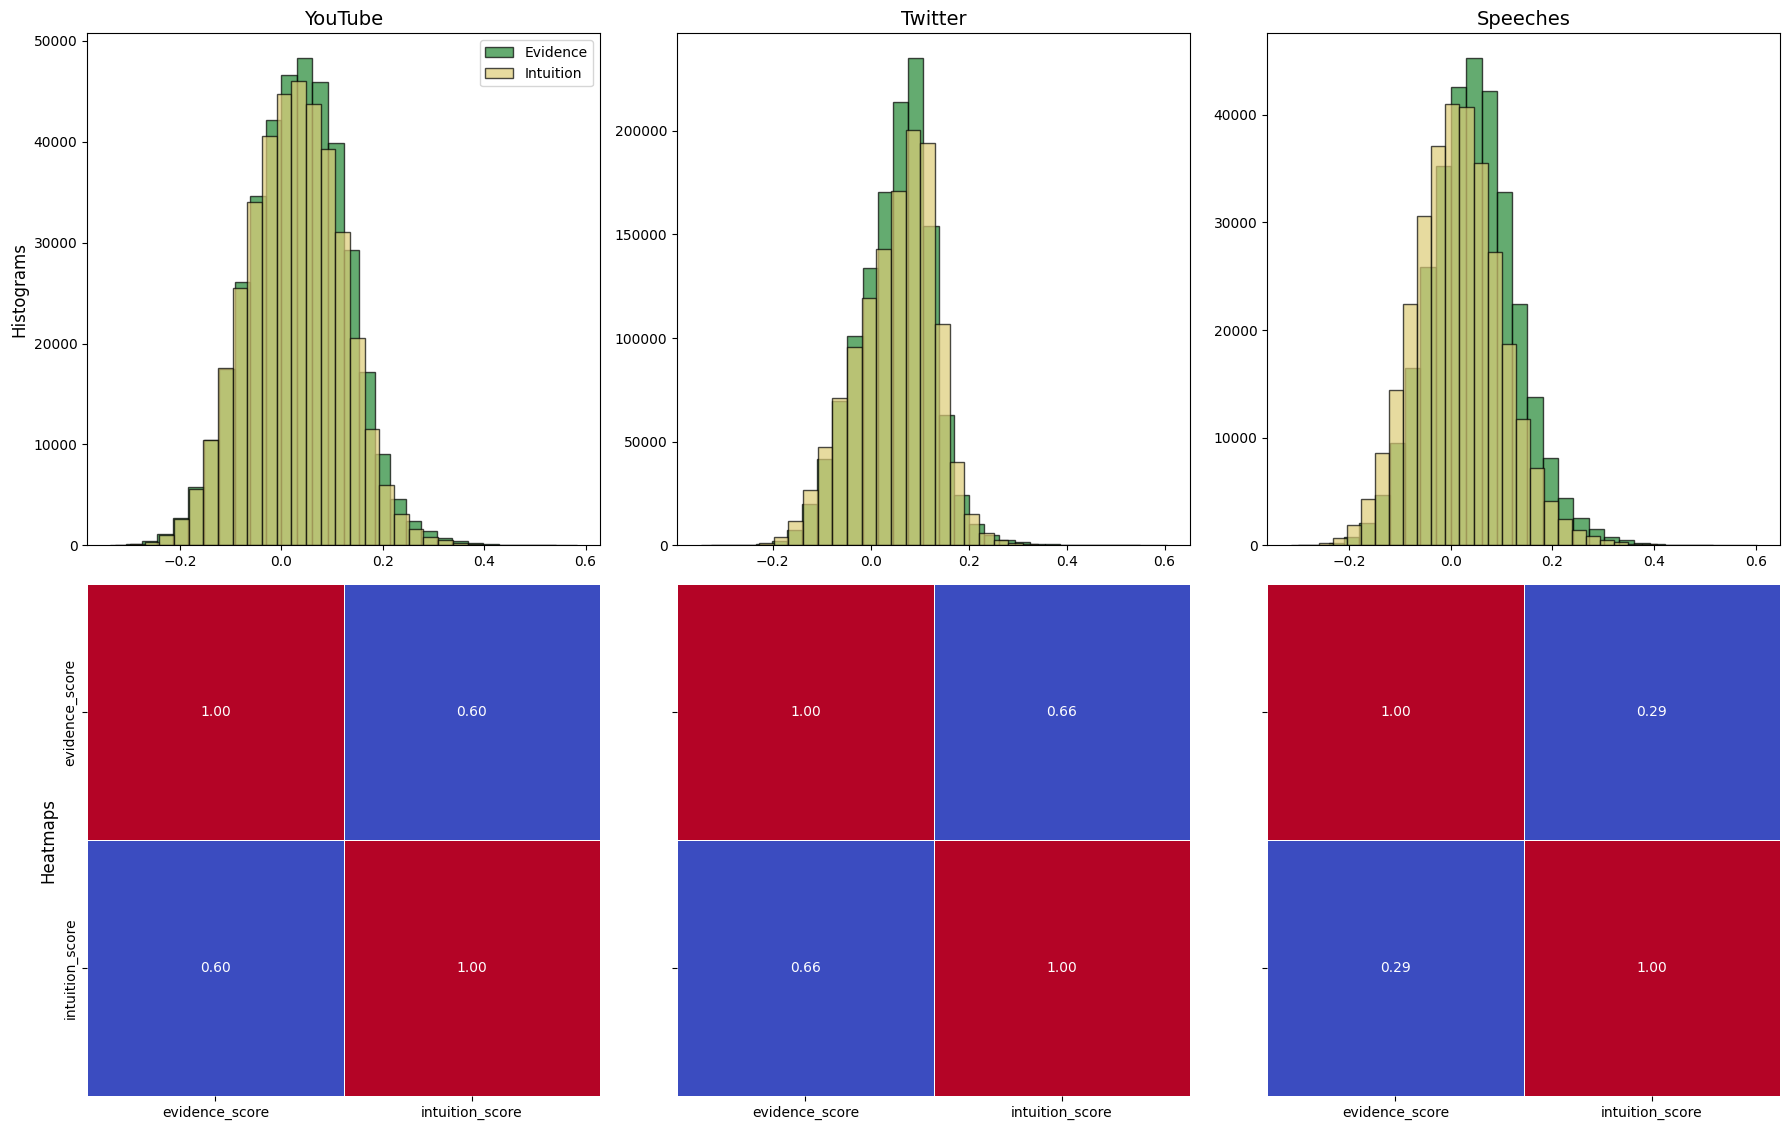

In [4]:
# Create a new figure with 2 rows, 3 columns
final_fig, final_axes = plt.subplots(2, len(text_columns), figsize=(18, 12))

# Loop through corpus datasets
for i, dataset_name in enumerate(text_columns):
    corpus_path = datasets[f"{dataset_name}_Corpus"]
    
    # Load corpus data
    corpus = pd.read_csv(corpus_path)

    # Drop duplicate words
    corpus = corpus.drop_duplicates(subset=['word'], keep='first')

    # Store Histograms in the final plot (word-level scores)
    ax_hist = final_axes[0, i]
    ax_hist.hist(corpus['evidence_score'].dropna(), bins=30, alpha=0.7, edgecolor='black', color=colors["evidence"], label="Evidence")
    ax_hist.hist(corpus['intuition_score'].dropna(), bins=30, alpha=0.7, edgecolor='black', color=colors["intuition"], label="Intuition")

    if i == 0:
        ax_hist.set_ylabel('Frequency')

    #ax_hist.set_xticklabels([])  # Remove x-tick labels
    #ax_hist.set_xticks([])  # Remove x-ticks

    # Compute correlation matrix for original corpus scores
    columns_of_interest = ['evidence_score', 'intuition_score']
    df_selected = corpus[columns_of_interest].dropna()
    correlation_matrix = df_selected.corr()

    # Store Heatmaps in the final plot
    ax_heatmap = final_axes[1, i]
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax_heatmap, cbar=False)

    if i == 0:
        ax_heatmap.set_ylabel('Variables')
        ax_hist.legend(loc='upper right')  # Add legend for colors
    else:
        ax_heatmap.set_yticklabels([])  # Hide y-tick labels for other columns

# Add dataset name as title per column
for i, dataset_name in enumerate(text_columns):
    final_axes[0, i].set_title(dataset_name, fontsize=14)

# Add row labels
final_axes[0, 0].set_ylabel("Histograms", fontsize=12)
final_axes[1, 0].set_ylabel("Heatmaps", fontsize=12)

# Global figure title
# final_fig.suptitle("Corpus-Level Analysis: Evidence & Intuition Scores", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout for spacing
plt.savefig("corpus_histograms_heatmaps.png")
plt.show()


In [5]:
def plot_clipped(data_path, corpus_path, text_col, data_string, date_col):
    global histograms, heatmaps, correlation_matrices, timeseries
    
    # Load data
    data = pd.read_csv(data_path)
    corpus = pd.read_csv(corpus_path)
    
    # Drop duplicate words
    corpus = corpus.drop_duplicates(subset=['word'], keep='first')
    
    # Create dictionary for quick lookup
    corpus_dict = corpus.set_index('word')[['evidence_score', 'intuition_score']].to_dict('index')

    tqdm.pandas()
    
    # Compute clipped scores
    data[['evidence_score_clipped', 'intuition_score_clipped']] = data[text_col].progress_apply(
        lambda x: pd.Series(compute_clipped_scores(x, corpus_dict))
    )

    data = length_adjustment_bin(data, "length", "clipped")
    data = evidence_minus_intuition_score(data, "clipped")
    
    
    # Histogram plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].hist(data['evidence_score_clipped'].dropna(), bins=30, alpha=0.7, edgecolor='black', color=colors["evidence"])
    axes[0].set_xlabel('Evidence Score Clipped')
    axes[0].set_ylabel('Frequency')
    
    axes[1].hist(data['intuition_score_clipped'].dropna(), bins=30, alpha=0.7, edgecolor='black', color=colors["intuition"])
    axes[1].set_xlabel('Intuition Score Clipped')
    
    plt.tight_layout()
    plt.savefig(f"clip_distibutions_transcripts_{data_string}.png")
    histograms.append(fig)
    plt.show()
    plt.close(fig)

    # Compute correlation matrix
    columns_of_interest = [
        'emi_w2vparliament', 'emi_clipped','evidence_score_clipped', 'intuition_score_clipped',
        'evidence_score_w2vparliament', 'intuition_score_w2vparliament'
    ]
    
    df_selected = data[columns_of_interest].dropna()
    correlation_matrix = df_selected.corr()
    correlation_matrices[data_string] = correlation_matrix
    
    # Heatmap plot
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax)
    plt.savefig(f"clip_correlation_{data_string}.png")
    heatmaps.append(fig)
    plt.show()
    plt.close(fig)


    ### TIME SERIES PLOT ###

    # Convert date column to datetime format
    data[date_col] = pd.to_datetime(data[date_col], errors='coerce')
    data = data.sort_values(by=date_col)  # Ensure chronological order

    fig = plt.figure(figsize=(12, 6))
    gs = gridspec.GridSpec(1, 1)

    ax_time = plt.subplot(gs[0, 0])
    ax_time.grid(True, axis='x')

    # Compute rolling mean for evidence and intuition scores
    rolling_window = '60D'
    evidence_rolling = data.set_index(date_col)['evidence_score_clipped'].rolling(rolling_window, center=True).mean()
    intuition_rolling = data.set_index(date_col)['intuition_score_clipped'].rolling(rolling_window, center=True).mean()

    # Resample quarterly for confidence intervals
    evidence_quarterly_avg = evidence_rolling.resample('Q').mean()
    intuition_quarterly_avg = intuition_rolling.resample('Q').mean()

    evidence_lower, evidence_upper = [], []
    intuition_lower, intuition_upper = [], []

    for quarter in evidence_quarterly_avg.index:
        quarterly_data = data[data[date_col].dt.to_period('Q') == quarter.to_period('Q')]
        
        lower, upper = bootstrap_ci(quarterly_data['evidence_score_clipped'].dropna())
        evidence_lower.append(lower)
        evidence_upper.append(upper)

        lower, upper = bootstrap_ci(quarterly_data['intuition_score_clipped'].dropna())
        intuition_lower.append(lower)
        intuition_upper.append(upper)

    evidence_lower = pd.Series(evidence_lower, index=evidence_quarterly_avg.index)
    evidence_upper = pd.Series(evidence_upper, index=evidence_quarterly_avg.index)
    
    intuition_lower = pd.Series(intuition_lower, index=intuition_quarterly_avg.index)
    intuition_upper = pd.Series(intuition_upper, index=intuition_quarterly_avg.index)

    # Plot Evidence
    ax_time.plot(evidence_quarterly_avg.index, evidence_quarterly_avg, color=colors["evidence"], marker='o', linewidth=1.5, label='Evidence')
    ax_time.fill_between(evidence_quarterly_avg.index, evidence_lower, evidence_upper, alpha=0.4, color=colors["evidence"])

    # Plot Intuition
    ax_time.plot(intuition_quarterly_avg.index, intuition_quarterly_avg, color=colors["intuition"], marker='o', linewidth=1.5, label='Intuition')
    ax_time.fill_between(intuition_quarterly_avg.index, intuition_lower, intuition_upper, alpha=0.4, color=colors["intuition"])

    ax_time.set_ylabel('Scores')
    ax_time.set_xlabel('Date')
    ax_time.legend()
    plt.tight_layout()

    timeseries.append(plt)
    
    plt.savefig(f"clip_timeseries_{data_string}.png")
    plt.show()
    plt.close(fig)
    return data


    

100%|██████████| 7552/7552 [00:10<00:00, 713.18it/s] 
<ipython-input-3-7ad003761111>:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'evidence_mean_{model_str}'] = df.groupby(f'{length_column}_bin')[f'evidence_score_{model_str}'].transform('mean')
<ipython-input-3-7ad003761111>:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'intuition_mean_{model_str}'] = df.groupby(f'{length_column}_bin')[f'intuition_score_{model_str}'].transform('mean')


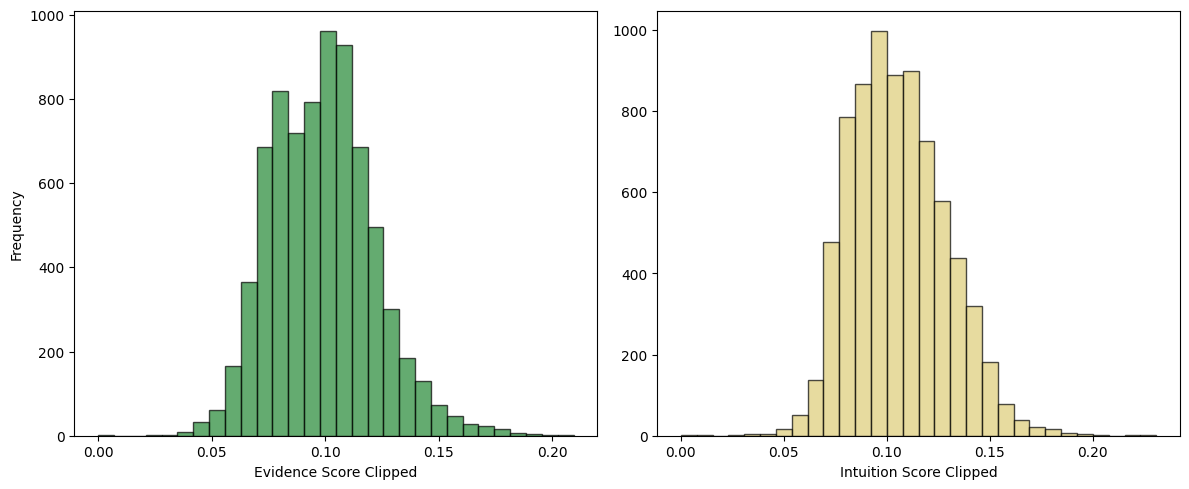

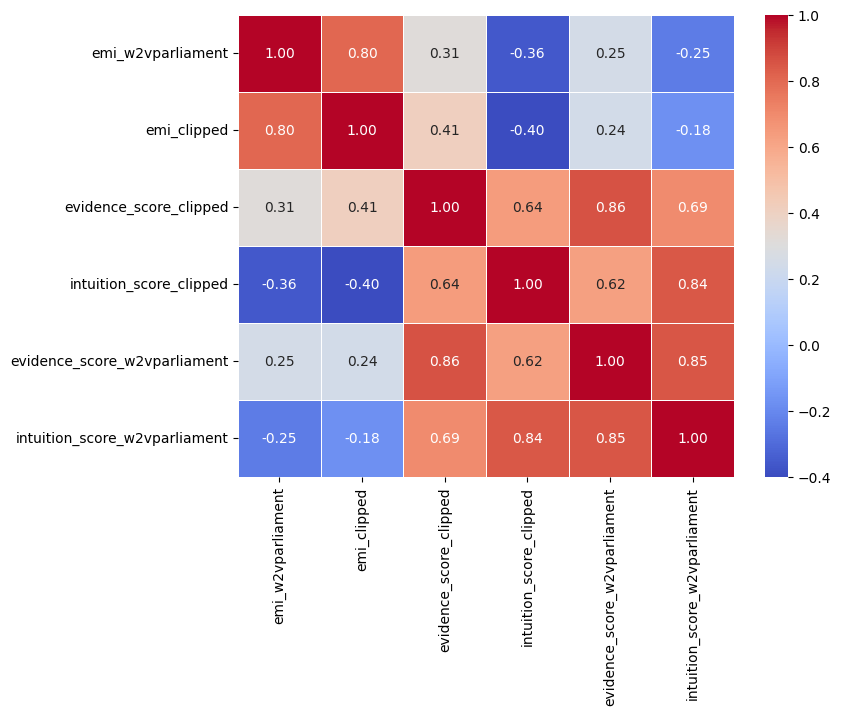

<ipython-input-5-270e4779ccde>:78: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  evidence_quarterly_avg = evidence_rolling.resample('Q').mean()
<ipython-input-5-270e4779ccde>:79: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  intuition_quarterly_avg = intuition_rolling.resample('Q').mean()
<ipython-input-5-270e4779ccde>:85: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  quarterly_data = data[data[date_col].dt.to_period('Q') == quarter.to_period('Q')]
<ipython-input-5-270e4779ccde>:85: UserWarning: Converting to Period representation will drop timezone information.
  quarterly_data = data[data[date_col].dt.to_period('Q') == quarter.to_period('Q')]


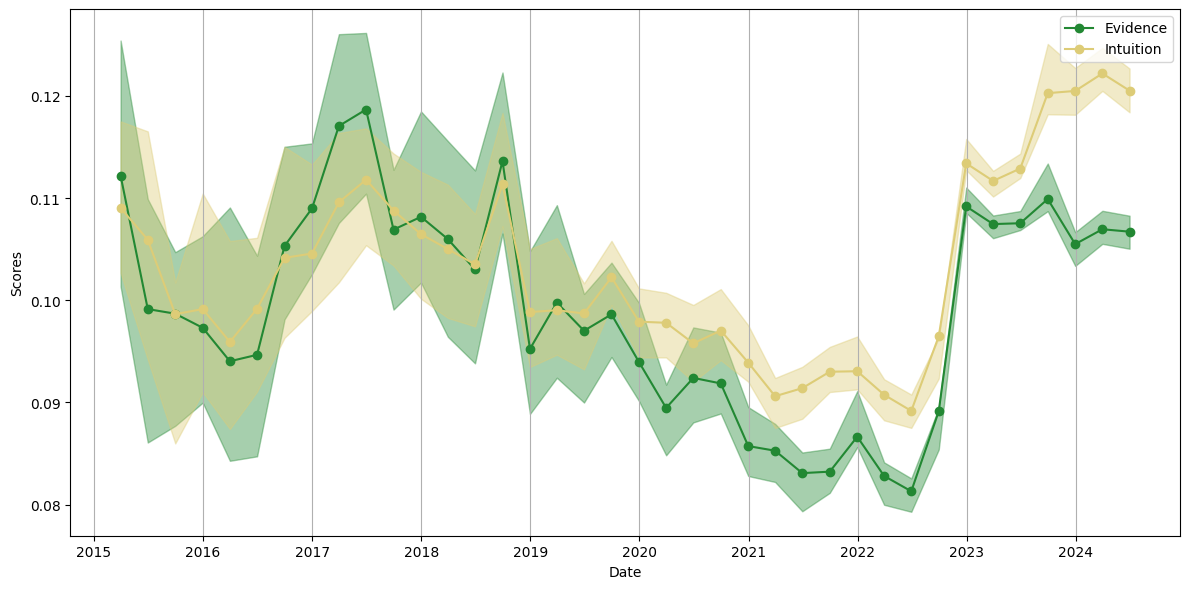

100%|██████████| 921676/921676 [01:56<00:00, 7905.49it/s] 
<ipython-input-3-7ad003761111>:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'evidence_mean_{model_str}'] = df.groupby(f'{length_column}_bin')[f'evidence_score_{model_str}'].transform('mean')
<ipython-input-3-7ad003761111>:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'intuition_mean_{model_str}'] = df.groupby(f'{length_column}_bin')[f'intuition_score_{model_str}'].transform('mean')


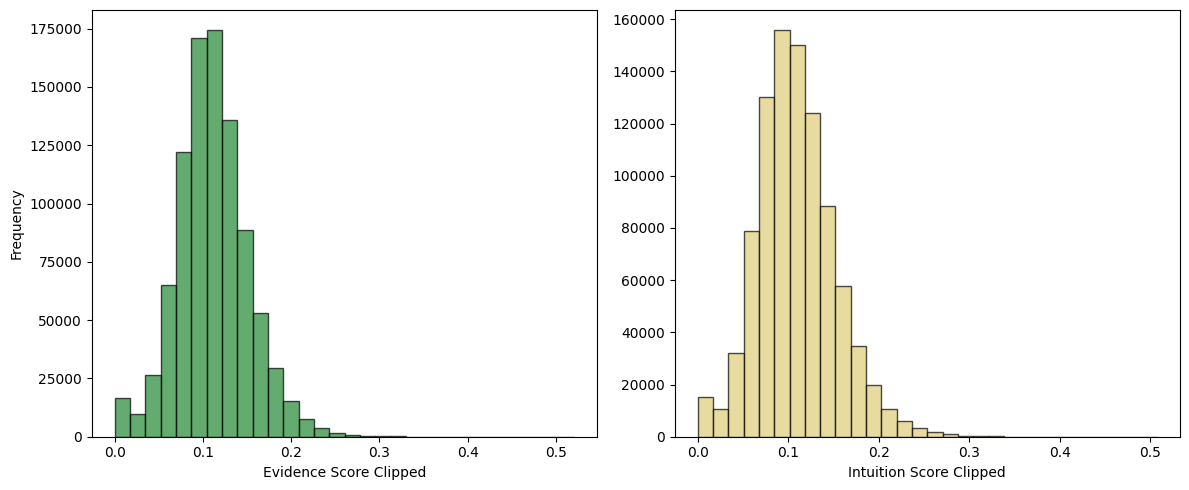

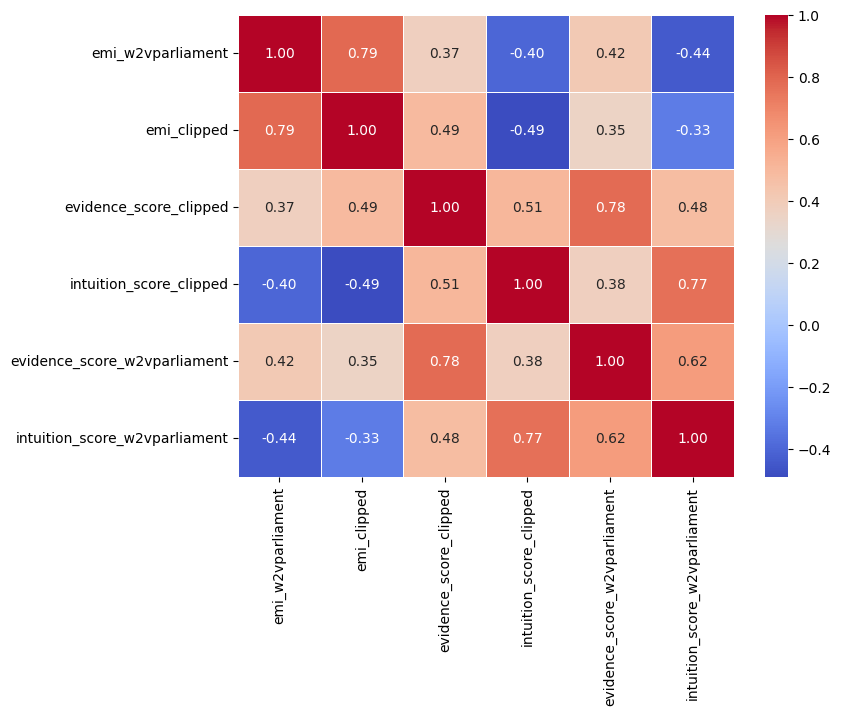

<ipython-input-5-270e4779ccde>:78: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  evidence_quarterly_avg = evidence_rolling.resample('Q').mean()
<ipython-input-5-270e4779ccde>:79: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  intuition_quarterly_avg = intuition_rolling.resample('Q').mean()
<ipython-input-5-270e4779ccde>:85: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  quarterly_data = data[data[date_col].dt.to_period('Q') == quarter.to_period('Q')]
<ipython-input-5-270e4779ccde>:85: UserWarning: Converting to Period representation will drop timezone information.
  quarterly_data = data[data[date_col].dt.to_period('Q') == quarter.to_period('Q')]


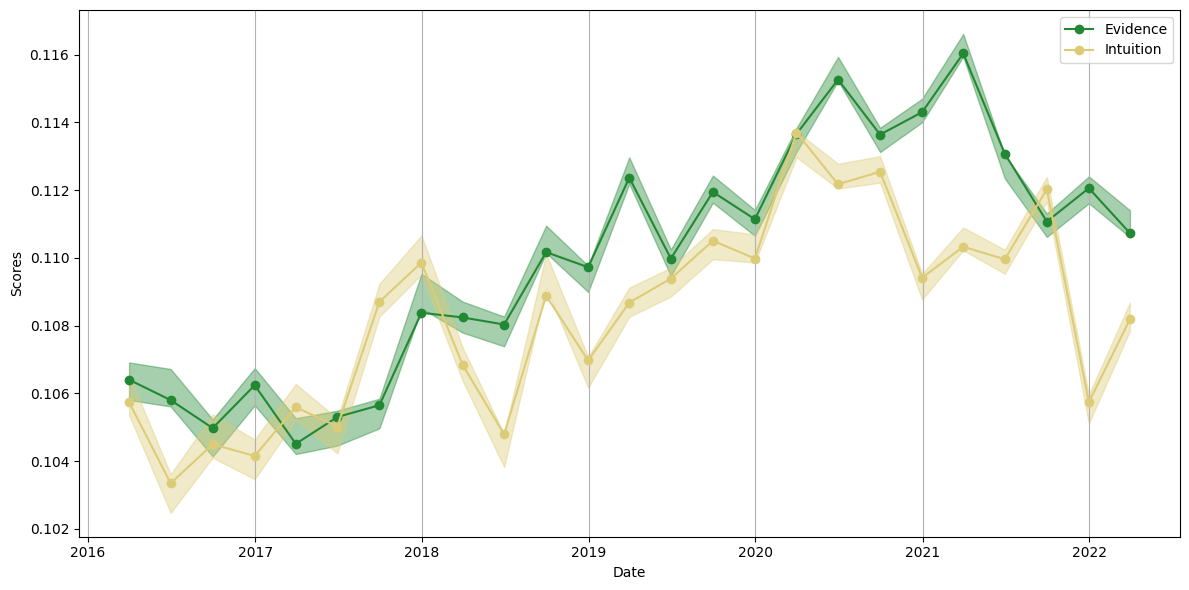

<ipython-input-5-270e4779ccde>:5: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path)
100%|██████████| 83715/83715 [00:20<00:00, 4132.57it/s]
<ipython-input-3-7ad003761111>:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'evidence_mean_{model_str}'] = df.groupby(f'{length_column}_bin')[f'evidence_score_{model_str}'].transform('mean')
<ipython-input-3-7ad003761111>:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'intuition_mean_{model_str}'] = df.groupby(f'{length_column}_bin')[f'intuition_score_{model_str}'].transform

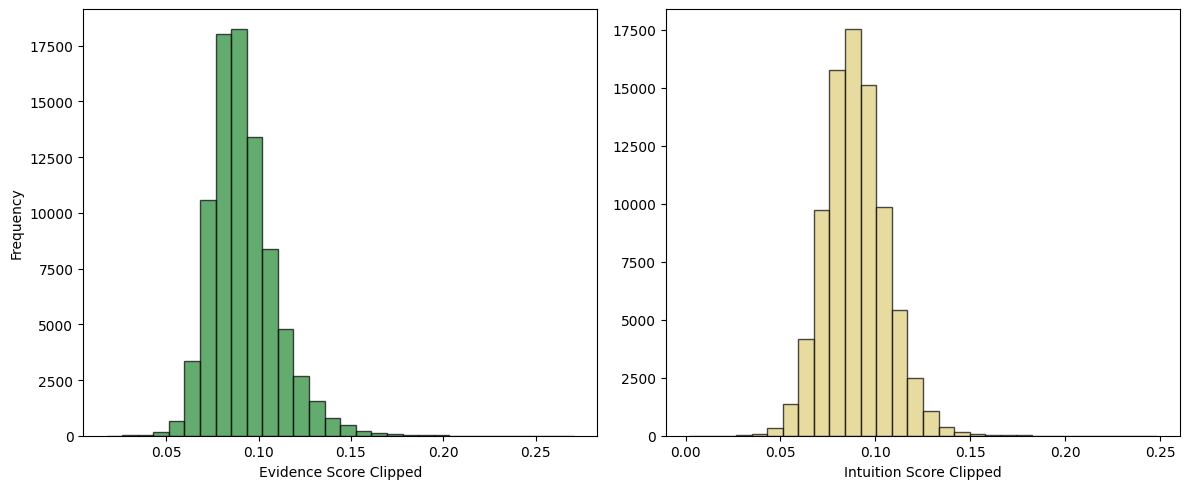

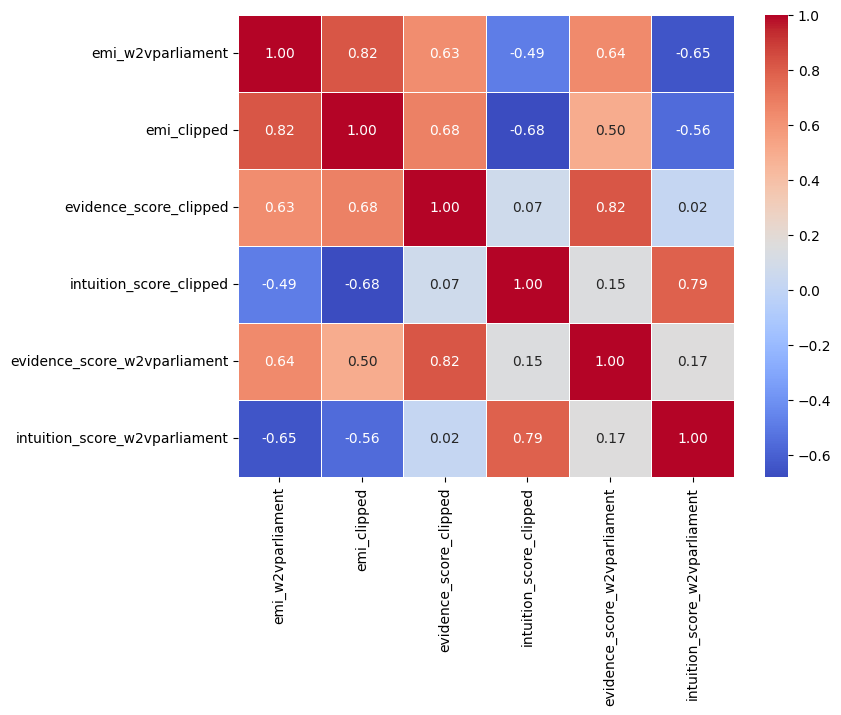

<ipython-input-5-270e4779ccde>:78: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  evidence_quarterly_avg = evidence_rolling.resample('Q').mean()
<ipython-input-5-270e4779ccde>:79: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  intuition_quarterly_avg = intuition_rolling.resample('Q').mean()


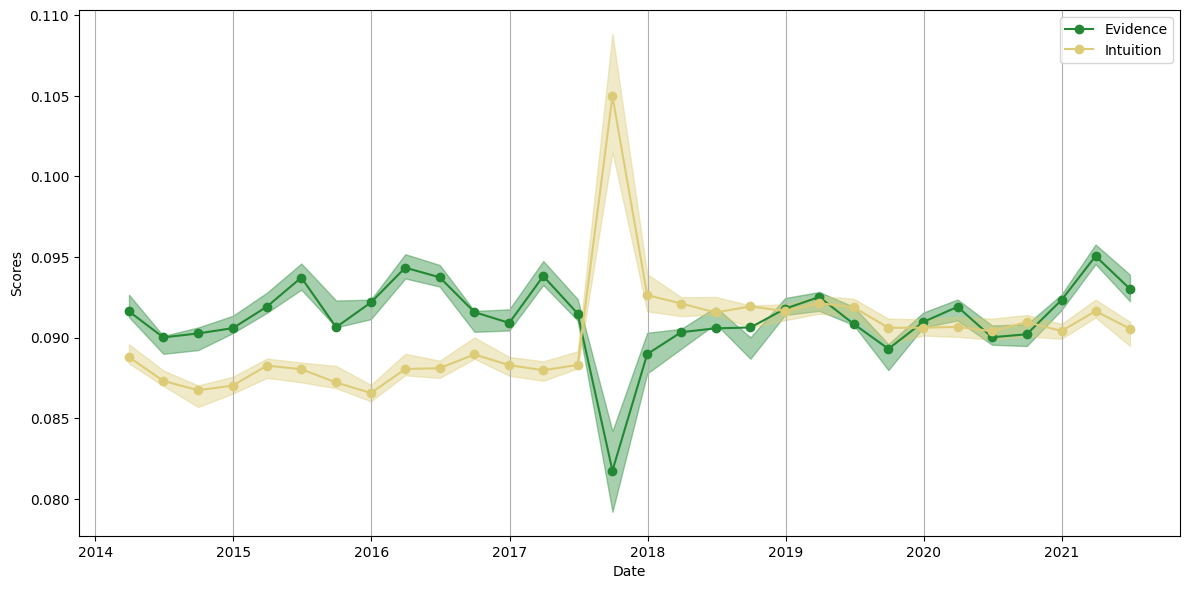

In [6]:
# Store plots for later
histograms = []
heatmaps = []
correlation_matrices = {}

timeseries = []


# Loop through datasets and call the function
for dataset_name in text_columns:
    data_path = datasets[dataset_name]
    date_col = date_columns[dataset_name]
    corpus_path = datasets[f"{dataset_name}_Corpus"]
    text_col = text_columns[dataset_name]
    data_string = dataset_name  # Pass the dataset name as a string

    data = plot_clipped(data_path, corpus_path, text_col, data_string, date_col)
    data.to_csv(f"{dataset_name}.csv")

100%|██████████| 7552/7552 [00:11<00:00, 658.74it/s] 
<ipython-input-3-7ad003761111>:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'evidence_mean_{model_str}'] = df.groupby(f'{length_column}_bin')[f'evidence_score_{model_str}'].transform('mean')
<ipython-input-3-7ad003761111>:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'intuition_mean_{model_str}'] = df.groupby(f'{length_column}_bin')[f'intuition_score_{model_str}'].transform('mean')
100%|██████████| 921676/921676 [01:52<00:00, 8185.50it/s] 
<ipython-input-3-7ad003761111>:37: FutureWarning: The default of observed=False is deprecated and wil

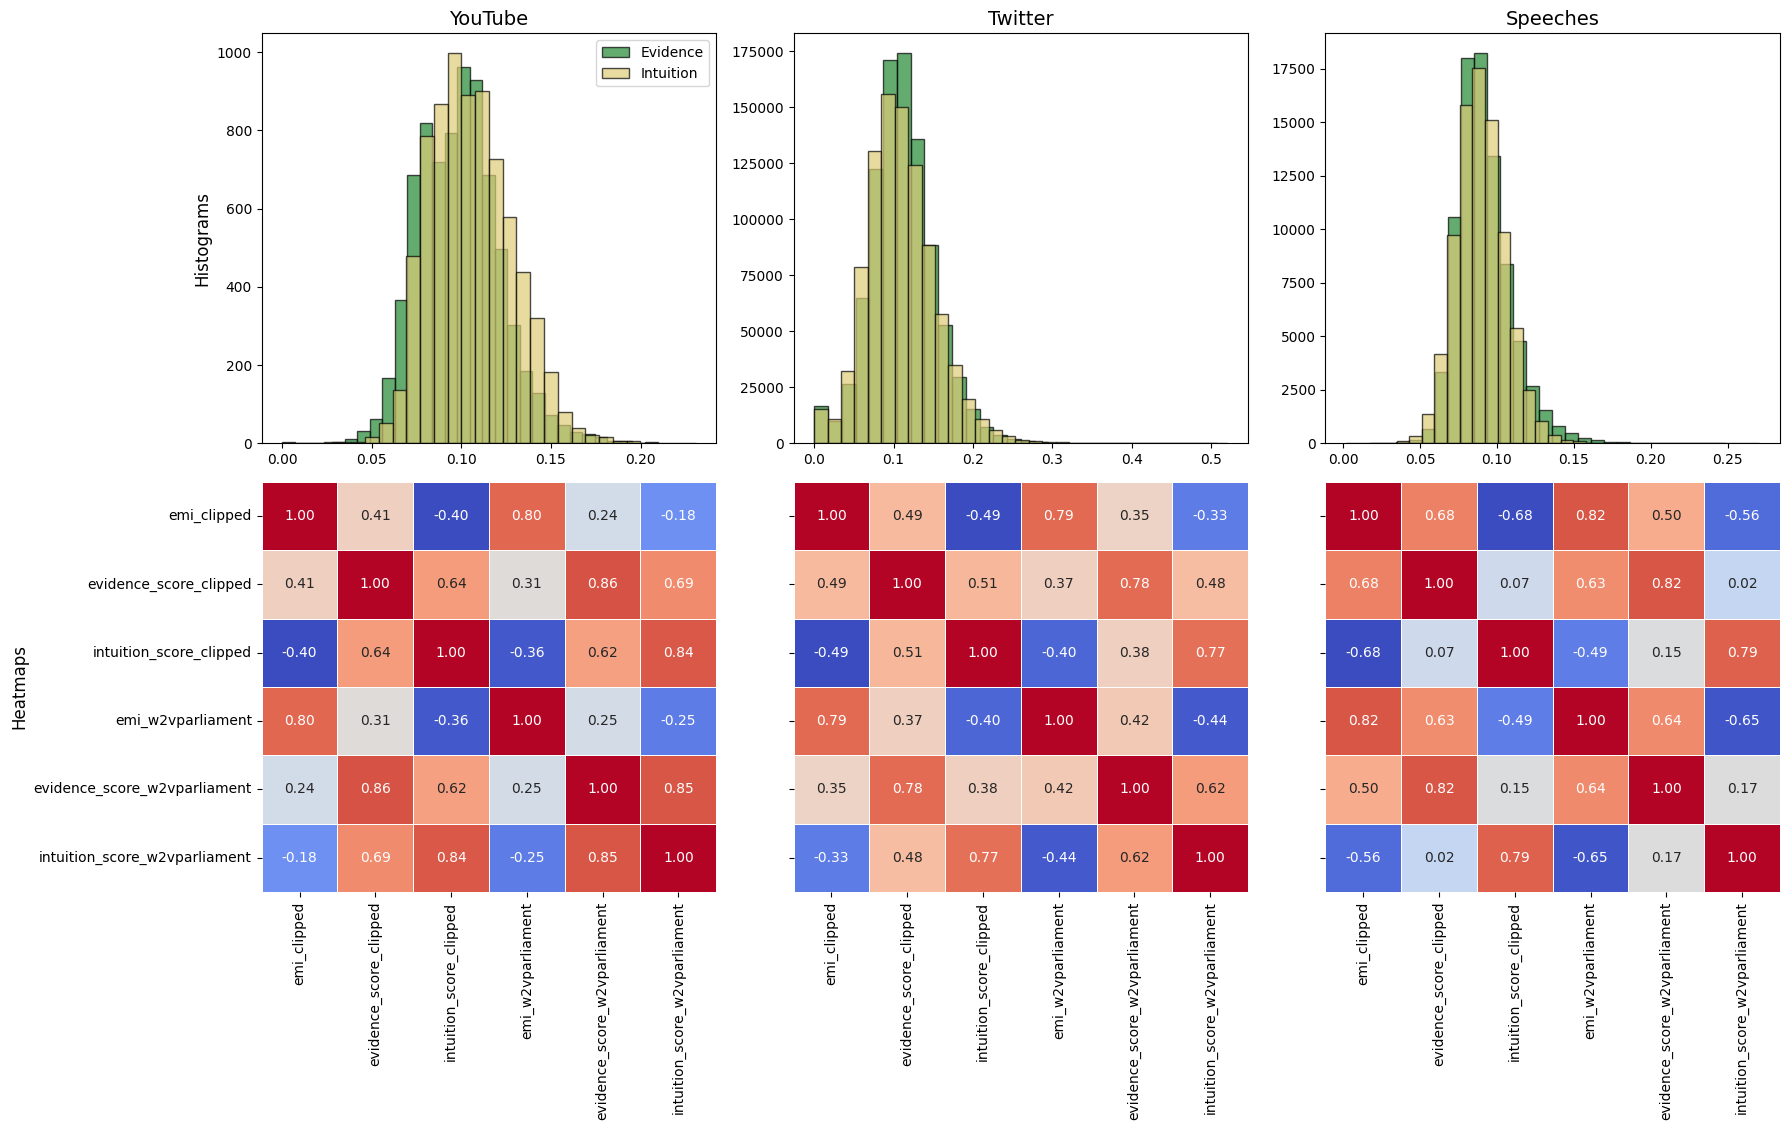

In [7]:
histograms = []
heatmaps = []
timeseries = []
correlation_matrices = {}

final_fig, final_axes = plt.subplots(2, 3, figsize=(18, 12))

# Loop through datasets and call the function
for i, dataset_name in enumerate(text_columns):
    data_path = datasets[dataset_name]
    date_col = date_columns[dataset_name]
    corpus_path = datasets[f"{dataset_name}_Corpus"]
    text_col = text_columns[dataset_name]
    data_string = dataset_name  # Pass the dataset name as a string

    # Load data
    data = pd.read_csv(data_path)
    corpus = pd.read_csv(corpus_path)
    
    # Drop duplicate words
    corpus = corpus.drop_duplicates(subset=['word'], keep='first')
    
    # Create dictionary for quick lookup
    corpus_dict = corpus.set_index('word')[['evidence_score', 'intuition_score']].to_dict('index')

    tqdm.pandas()
    
    # Compute clipped scores
    data[['evidence_score_clipped', 'intuition_score_clipped']] = data[text_col].progress_apply(
        lambda x: pd.Series(compute_clipped_scores(x, corpus_dict))
    )
    data = length_adjustment_bin(data, "length", "clipped")
    data = evidence_minus_intuition_score(data, "clipped")
    
    # Store Histograms in the final plot
    ax_hist = final_axes[0, i]
    ax_hist.hist(data['evidence_score_clipped'].dropna(), bins=30, alpha=0.7, edgecolor='black', color=colors["evidence"], label="Evidence")
    ax_hist.hist(data['intuition_score_clipped'].dropna(), bins=30, alpha=0.7, edgecolor='black', color=colors["intuition"], label="Intuition")
    if i == 0:
        ax_hist.set_ylabel('Frequency')
        ax_hist.legend(loc='upper right')  # Add legend for colors

    # Compute correlation matrix
    columns_of_interest = [
        'emi_clipped', 'evidence_score_clipped', 'intuition_score_clipped',
        'emi_w2vparliament', 'evidence_score_w2vparliament', 'intuition_score_w2vparliament'
    ]
    
    df_selected = data[columns_of_interest].dropna()
    correlation_matrix = df_selected.corr()
    correlation_matrices[data_string] = correlation_matrix

    # Store Heatmaps in the final plot
    ax_heatmap = final_axes[1, i]
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax_heatmap, cbar=False)

    if i == 0:
        ax_heatmap.set_ylabel('Variables')
        
    else:
        ax_heatmap.set_yticklabels([])  # Hide y-tick labels for other columns

# Add dataset name as title per column
for i, dataset_name in enumerate(text_columns):
    final_axes[0, i].set_title(dataset_name, fontsize=14)

# Add row labels
final_axes[0, 0].set_ylabel("Histograms", fontsize=12)
final_axes[1, 0].set_ylabel("Heatmaps", fontsize=12)

# Global figure title
#final_fig.suptitle("Comparison of Datasets", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout for title
plt.savefig("corpus_histograms_heatmaps_clipped.png")
plt.show()

100%|██████████| 7552/7552 [00:10<00:00, 694.41it/s] 
<ipython-input-3-7ad003761111>:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'evidence_mean_{model_str}'] = df.groupby(f'{length_column}_bin')[f'evidence_score_{model_str}'].transform('mean')
<ipython-input-3-7ad003761111>:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'intuition_mean_{model_str}'] = df.groupby(f'{length_column}_bin')[f'intuition_score_{model_str}'].transform('mean')
<ipython-input-8-04264578c218>:33: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  evidence_quarterly_avg =

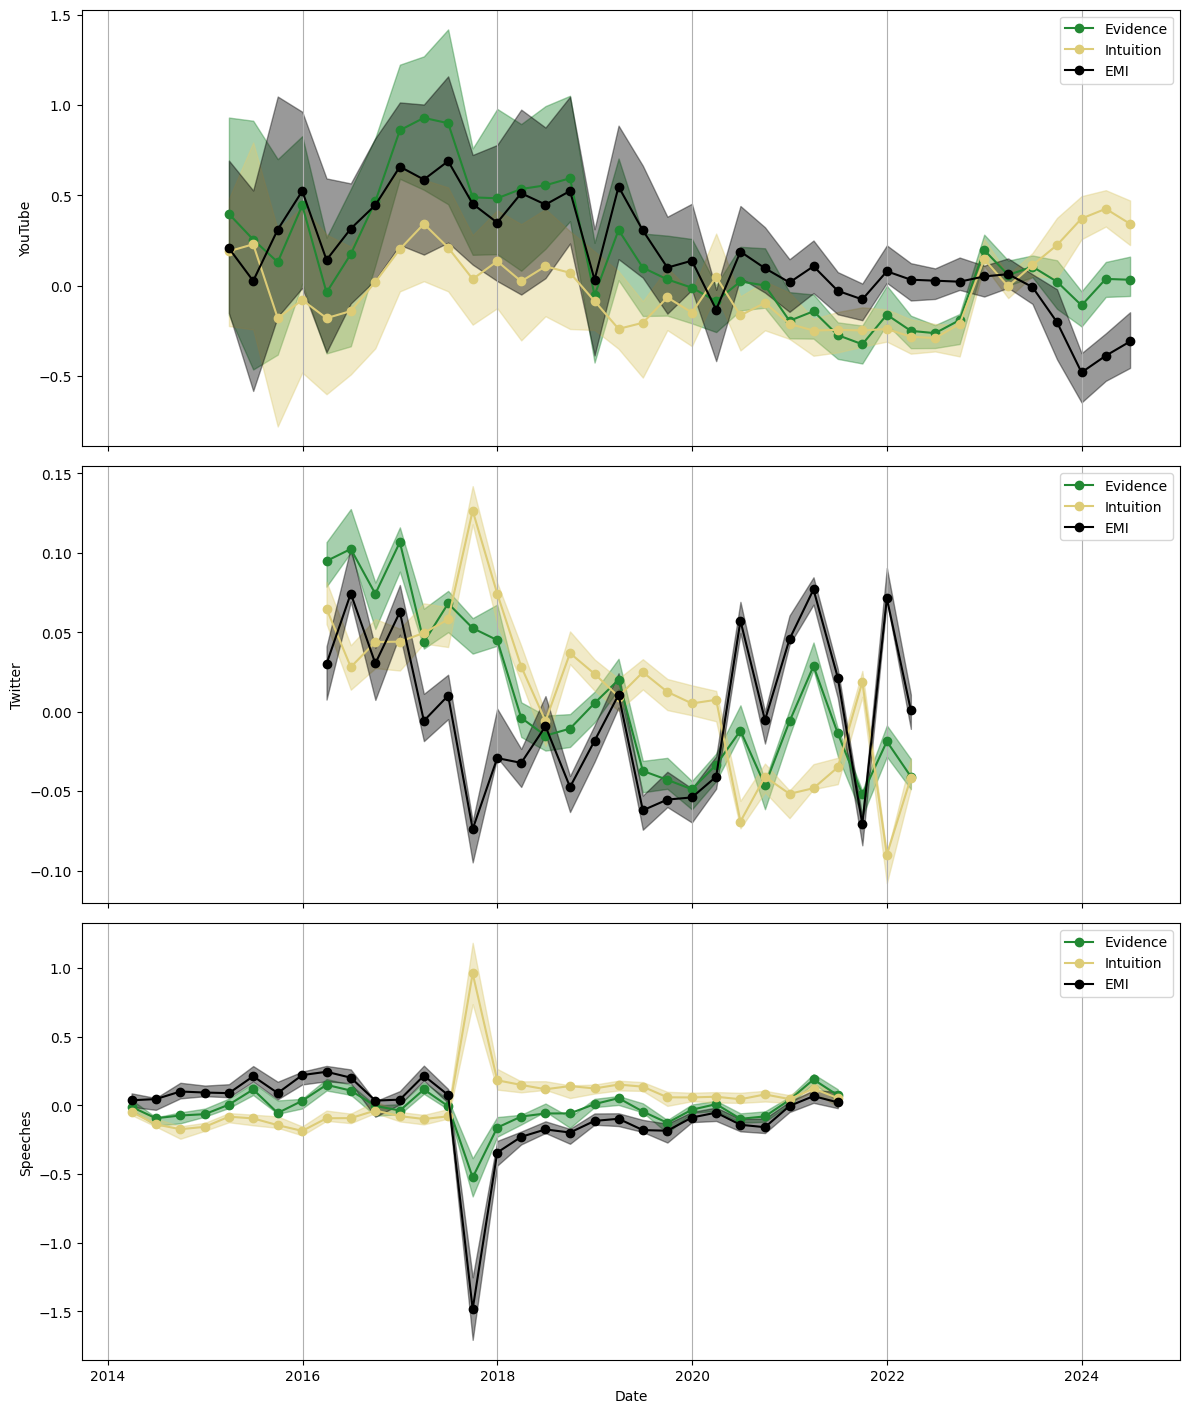

In [8]:
# Create a new figure for time series plots
time_fig, time_axes = plt.subplots(len(text_columns), 1, figsize=(12, 15), sharex=True)

# Loop through datasets and create time series plots
for i, dataset_name in enumerate(text_columns):
    data_path = datasets[dataset_name]
    date_col = date_columns[dataset_name]
    text_col = text_columns[dataset_name]

    # Load data
    data = pd.read_csv(data_path)

    # Compute clipped scores
    data[['evidence_score_clipped', 'intuition_score_clipped']] = data[text_col].progress_apply(
        lambda x: pd.Series(compute_clipped_scores(x, corpus_dict))
    )

    data = length_adjustment_bin(data, "length", "clipped")

    data = evidence_minus_intuition_score(data, "clipped")

    # Convert date column to datetime format
    data[date_col] = pd.to_datetime(data[date_col], errors='coerce')
    data = data.sort_values(by=date_col)  # Ensure chronological order

    # Compute rolling mean for evidence and intuition scores
    rolling_window = '60D'
    evidence_rolling = data.set_index(date_col)['evidence_z_clipped'].rolling(rolling_window, center=True).mean()
    intuition_rolling = data.set_index(date_col)['intuition_z_clipped'].rolling(rolling_window, center=True).mean()
    emi_rolling = data.set_index(date_col)['emi_clipped'].rolling(rolling_window, center=True).mean()

    # Resample quarterly for confidence intervals
    evidence_quarterly_avg = evidence_rolling.resample('Q').mean()
    intuition_quarterly_avg = intuition_rolling.resample('Q').mean()
    emi_quarterly_avg = emi_rolling.resample('Q').mean()

    evidence_lower, evidence_upper = [], []
    intuition_lower, intuition_upper = [], []
    emi_lower, emi_upper = [], []

    for quarter in evidence_quarterly_avg.index:
        quarterly_data = data[data[date_col].dt.to_period('Q') == quarter.to_period('Q')]

        lower, upper = bootstrap_ci(quarterly_data['evidence_z_clipped'].dropna())
        evidence_lower.append(lower)
        evidence_upper.append(upper)

        lower, upper = bootstrap_ci(quarterly_data['intuition_z_clipped'].dropna())
        intuition_lower.append(lower)
        intuition_upper.append(upper)

        lower, upper = bootstrap_ci(quarterly_data['emi_clipped'].dropna())
        emi_lower.append(lower)
        emi_upper.append(upper)

    evidence_lower = pd.Series(evidence_lower, index=evidence_quarterly_avg.index)
    evidence_upper = pd.Series(evidence_upper, index=evidence_quarterly_avg.index)

    intuition_lower = pd.Series(intuition_lower, index=intuition_quarterly_avg.index)
    intuition_upper = pd.Series(intuition_upper, index=intuition_quarterly_avg.index)

    emi_lower = pd.Series(emi_lower, index=evidence_quarterly_avg.index)
    emi_upper = pd.Series(emi_upper, index=evidence_quarterly_avg.index)

    # Plot the time series
    ax_time = time_axes[i]
    ax_time.grid(True, axis='x')

    ax_time.plot(evidence_quarterly_avg.index, evidence_quarterly_avg, color=colors["evidence"], marker='o', linewidth=1.5, label='Evidence')
    ax_time.fill_between(evidence_quarterly_avg.index, evidence_lower, evidence_upper, alpha=0.4, color=colors["evidence"])

    ax_time.plot(intuition_quarterly_avg.index, intuition_quarterly_avg, color=colors["intuition"], marker='o', linewidth=1.5, label='Intuition')
    ax_time.fill_between(intuition_quarterly_avg.index, intuition_lower, intuition_upper, alpha=0.4, color=colors["intuition"])

    ax_time.plot(emi_quarterly_avg.index, emi_quarterly_avg, color="black", marker='o', linewidth=1.5, label='EMI')
    ax_time.fill_between(emi_quarterly_avg.index, emi_lower, emi_upper, alpha=0.4, color="black")


    ax_time.set_ylabel(dataset_name)  # Label each row with dataset name
    if i == len(text_columns) - 1:
        ax_time.set_xlabel("Date")  # Only the last plot gets an x-label

    ax_time.legend()

# Global figure title
#time_fig.suptitle("Time Series Trends per Dataset", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout for title
time_fig.savefig("combined_timeseries_clipped.png")

plt.show()

<ipython-input-9-3329dc3efbc6>:31: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  emi_quarterly_avg = emi_rolling.resample('Q').mean()
<ipython-input-9-3329dc3efbc6>:32: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  intuition_quarterly_avg = intuition_rolling.resample('Q').mean()
<ipython-input-9-3329dc3efbc6>:33: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  evidence_quarterly_avg = evidence_rolling.resample('Q').mean()
<ipython-input-9-3329dc3efbc6>:40: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  quarterly_data = data[data[date_col].dt.to_period('Q') == quarter.to_period('Q')]
<ipython-input-9-3329dc3efbc6>:40: UserWarning: Converting to Period representation will drop timezone information.
  quarterly_data = data[data[date_col].dt.to_period('Q') == quarter.to_period('Q')]


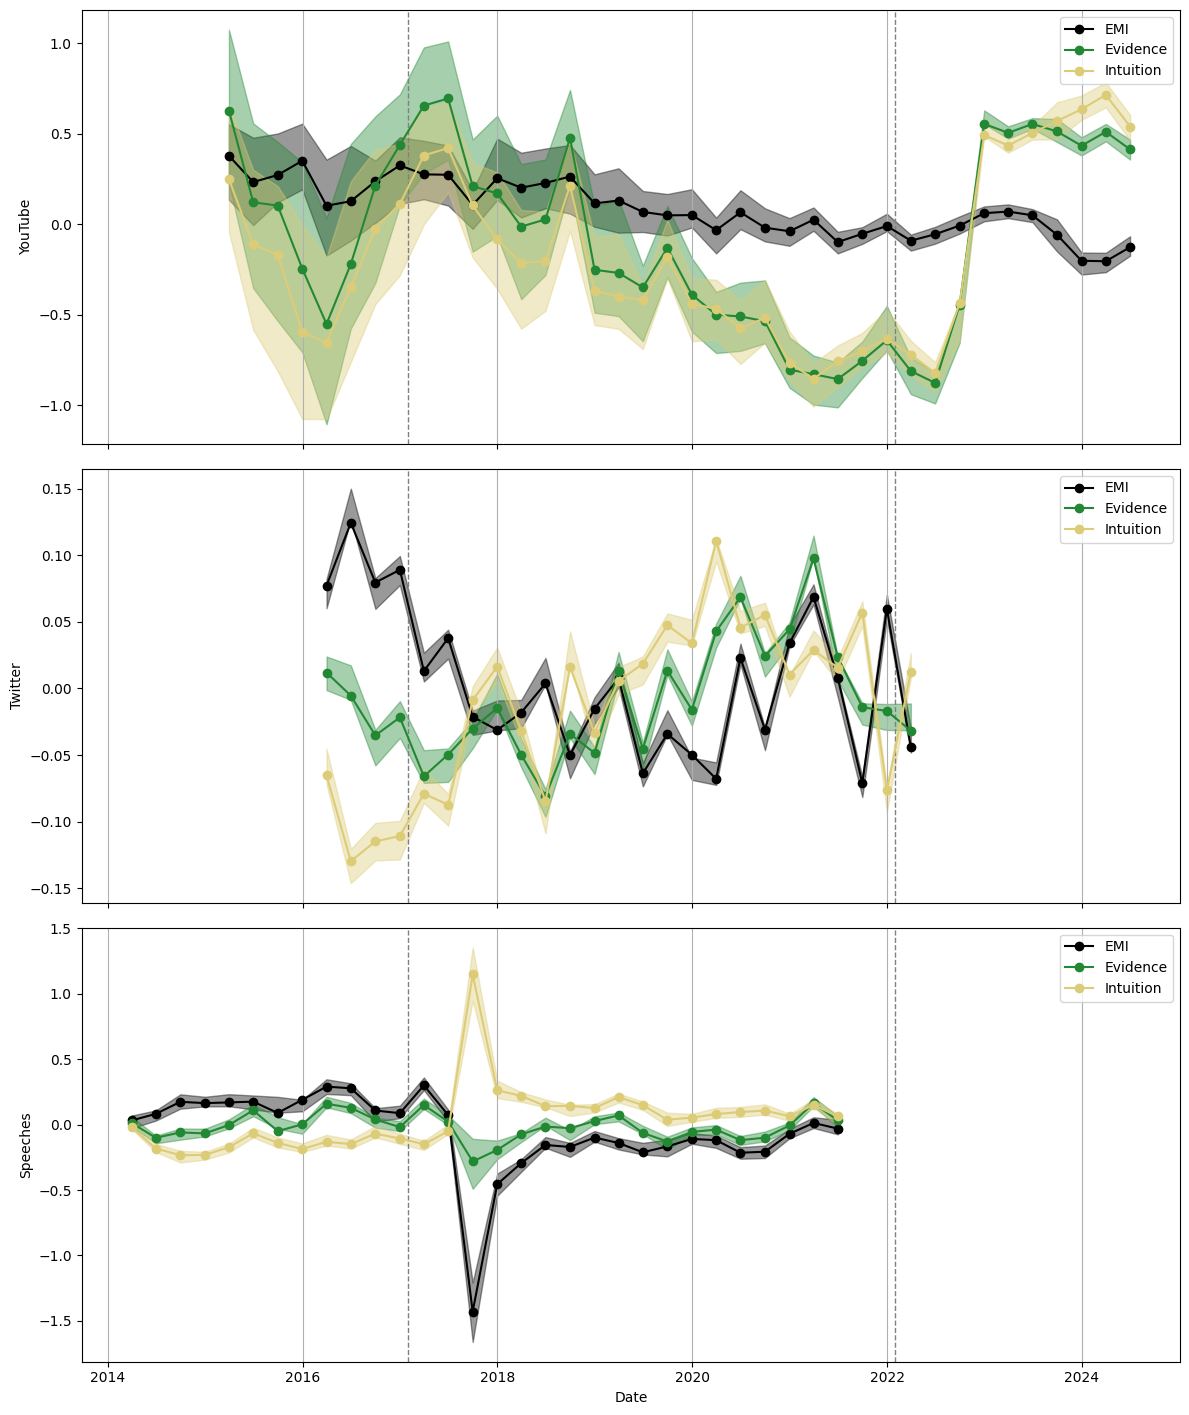

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Define the vertical lines for Q1 2017 and Q1 2022
vline_dates = [pd.Timestamp("2017-02-01"), pd.Timestamp("2022-02-01")]

# Create a new figure for time series plots
time_fig, time_axes = plt.subplots(len(text_columns), 1, figsize=(12, 15), sharex=True)

# Loop through datasets and create time series plots
for i, dataset_name in enumerate(text_columns):
    data_path = datasets[dataset_name]
    date_col = date_columns[dataset_name]

    # Load data
    data = pd.read_csv(data_path)

    # Convert date column to datetime format
    data[date_col] = pd.to_datetime(data[date_col], errors='coerce')
    data = data.sort_values(by=date_col)  # Ensure chronological order

    # Compute rolling mean for original score columns
    rolling_window = '60D'
    emi_rolling = data.set_index(date_col)['emi_w2vparliament'].rolling(rolling_window, center=True).mean()
    intuition_rolling = data.set_index(date_col)['intuition_z_w2vparliament'].rolling(rolling_window, center=True).mean()
    evidence_rolling = data.set_index(date_col)['evidence_z_w2vparliament'].rolling(rolling_window, center=True).mean()

    # Resample quarterly for confidence intervals
    emi_quarterly_avg = emi_rolling.resample('Q').mean()
    intuition_quarterly_avg = intuition_rolling.resample('Q').mean()
    evidence_quarterly_avg = evidence_rolling.resample('Q').mean()

    emi_lower, emi_upper = [], []
    intuition_lower, intuition_upper = [], []
    evidence_lower, evidence_upper = [], []

    for quarter in emi_quarterly_avg.index:
        quarterly_data = data[data[date_col].dt.to_period('Q') == quarter.to_period('Q')]

        lower, upper = bootstrap_ci(quarterly_data['emi_w2vparliament'].dropna())
        emi_lower.append(lower)
        emi_upper.append(upper)

        lower, upper = bootstrap_ci(quarterly_data['intuition_z_w2vparliament'].dropna())
        intuition_lower.append(lower)
        intuition_upper.append(upper)

        lower, upper = bootstrap_ci(quarterly_data['evidence_z_w2vparliament'].dropna())
        evidence_lower.append(lower)
        evidence_upper.append(upper)

    emi_lower = pd.Series(emi_lower, index=emi_quarterly_avg.index)
    emi_upper = pd.Series(emi_upper, index=emi_quarterly_avg.index)

    intuition_lower = pd.Series(intuition_lower, index=intuition_quarterly_avg.index)
    intuition_upper = pd.Series(intuition_upper, index=intuition_quarterly_avg.index)

    evidence_lower = pd.Series(evidence_lower, index=evidence_quarterly_avg.index)
    evidence_upper = pd.Series(evidence_upper, index=evidence_quarterly_avg.index)

    # Plot the time series
    ax_time = time_axes[i]
    ax_time.grid(True, axis='x')

    # Add vertical dashed grey lines at Q1 2017 and Q1 2022
    for vline_date in vline_dates:
        ax_time.axvline(vline_date, color='grey', linestyle='dashed', linewidth=1)

    # EMI in black
    ax_time.plot(emi_quarterly_avg.index, emi_quarterly_avg, color="black", marker='o', linestyle='-', linewidth=1.5, label='EMI')
    ax_time.fill_between(emi_quarterly_avg.index, emi_lower, emi_upper, alpha=0.4, color="black")

    # Evidence in original color
    ax_time.plot(evidence_quarterly_avg.index, evidence_quarterly_avg, color=colors["evidence"], marker='o', linestyle='-', linewidth=1.5, label='Evidence')
    ax_time.fill_between(evidence_quarterly_avg.index, evidence_lower, evidence_upper, alpha=0.4, color=colors["evidence"])

    # Intuition in original color
    ax_time.plot(intuition_quarterly_avg.index, intuition_quarterly_avg, color=colors["intuition"], marker='o', linestyle='-', linewidth=1.5, label='Intuition')
    ax_time.fill_between(intuition_quarterly_avg.index, intuition_lower, intuition_upper, alpha=0.4, color=colors["intuition"])

    ax_time.set_ylabel(dataset_name)  # Label each row with dataset name
    if i == len(text_columns) - 1:
        ax_time.set_xlabel("Date")  # Only the last plot gets an x-label

    ax_time.legend()

# Global figure title
#time_fig.suptitle("Time Series Trends per Dataset (Original Scores)", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout for title
time_fig.savefig("combined_timeseries_original.png")

plt.show()


